# Use Case 01: Protein Structure and Binding-Site Prediction via VQE

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from qiskit.circuit.library import RealAmplitudes
from qiskit.quantum_info import SparsePauliOp
from scipy.optimize import minimize

hamiltonian = SparsePauliOp.from_list([
    ("II", 0.5),
    ("ZI", -0.5),
    ("IZ", -0.5),
    ("ZZ", 1.0)
])

print("Hamiltonian operator:")
print(hamiltonian)

Hamiltonian operator:
SparsePauliOp(['II', 'ZI', 'IZ', 'ZZ'],
              coeffs=[ 0.5+0.j, -0.5+0.j, -0.5+0.j,  1. +0.j])


C:\Users\JYOTI PRAKASH\AppData\Local\Temp\ipykernel_666052\3765517471.py:1: DeprecationWarning: The class ``qiskit.circuit.library.n_local.real_amplitudes.RealAmplitudes`` is deprecated as of Qiskit 2.1. It will be removed in Qiskit 3.0. Use the function qiskit.circuit.library.real_amplitudes instead.
  ansatz = RealAmplitudes(num_qubits=2, reps=2, entanglement="full")


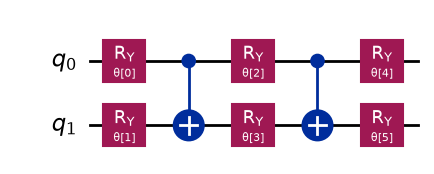

In [2]:
ansatz = RealAmplitudes(num_qubits=2, reps=2, entanglement="full")
ansatz.decompose().draw("mpl")

Optimal Energy Found: -0.49999999933035033
Optimization Success: True


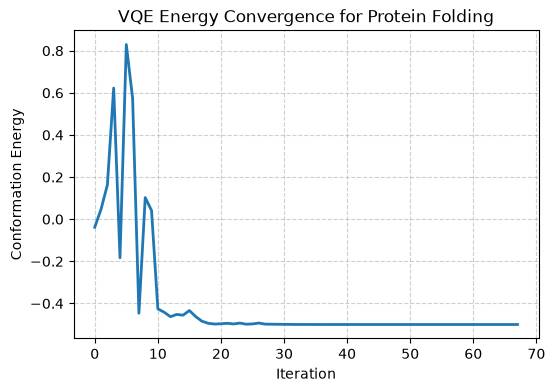

In [3]:
from qiskit.quantum_info import Statevector

loss_history = []

def cost_function(params):
    bound_circuit = ansatz.assign_parameters(params)
    sv = Statevector(bound_circuit)
    energy = sv.expectation_value(hamiltonian).real
    loss_history.append(energy)
    return energy

initial_params = np.random.uniform(0, 2 * np.pi, ansatz.num_parameters)

result = minimize(cost_function, initial_params, method="COBYLA", options={"maxiter": 100})

print("Optimal Energy Found:", result.fun)
print("Optimization Success:", result.success)

plt.figure(figsize=(6, 4))
plt.plot(loss_history, color="#1f77b4", linewidth=2)
plt.title("VQE Energy Convergence for Protein Folding")
plt.xlabel("Iteration")
plt.ylabel("Conformation Energy")
plt.grid(True, linestyle="--", alpha=0.6)
plt.show()

Optimal Conformation Bitstring: 10
All State Probabilities: {np.str_('00'): np.float64(5.431034321987313e-10), np.str_('01'): np.float64(0.17050399622608023), np.str_('10'): np.float64(0.829496003188634), np.str_('11'): np.float64(4.218206927750858e-11)}


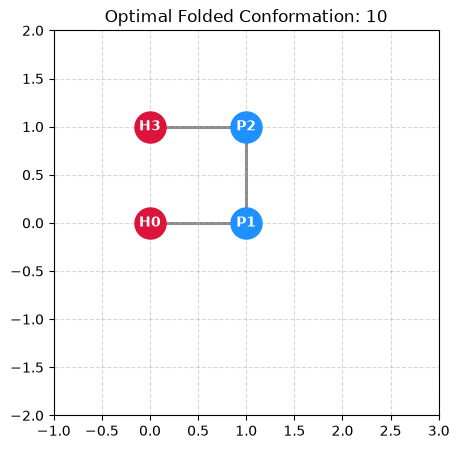

In [4]:
from qiskit.quantum_info import Statevector

final_circuit = ansatz.assign_parameters(result.x)
final_sv = Statevector(final_circuit)
probs = final_sv.probabilities_dict()

# Pick the highest probability conformation bitstring
best_bitstring = max(probs, key=probs.get)
print("Optimal Conformation Bitstring:", best_bitstring)
print("All State Probabilities:", probs)

# Coordinate reconstruction on 2D square lattice
# Coordinates for H-P-P-H
coords = [(0, 0), (1, 0)]  # Bead 0, Bead 1

# Decode turns from bitstring (q1 q0)
b0 = int(best_bitstring[-1])
b1 = int(best_bitstring[-2])

# Bead 2
y2 = 1 if b0 == 0 else -1
coords.append((1, y2))

# Bead 3
x3 = 0 if b1 == 1 else 2
coords.append((x3, y2))

xs, ys = zip(*coords)
labels = ["H0", "P1", "P2", "H3"]
colors = ["crimson", "dodgerblue", "dodgerblue", "crimson"]

plt.figure(figsize=(5, 5))
plt.plot(xs, ys, "-o", color="gray", linewidth=2, zorder=1)

for i, (x, y) in enumerate(coords):
    plt.scatter(x, y, color=colors[i], s=500, zorder=2)
    plt.text(x, y, labels[i], color="white", weight="bold", ha="center", va="center")

plt.title(f"Optimal Folded Conformation: {best_bitstring}")
plt.xlim(-1, 3)
plt.ylim(-2, 2)
plt.grid(True, linestyle="--", alpha=0.5)
plt.gca().set_aspect("equal")
plt.show()

--- Benchmark Results ---
Exact Classical Ground State Energy : -0.5000
VQE Optimized Quantum Energy        : -0.5000
Energy Approximation Error          : 0.000000


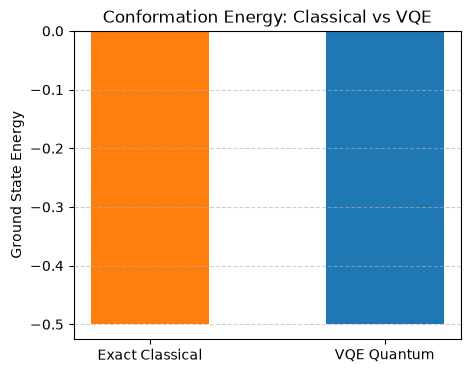

In [5]:
# Exact diagonalisation (classical ground truth)
eigvals, _ = np.linalg.eigh(hamiltonian.to_matrix())
exact_ground_energy = eigvals[0]

print("--- Benchmark Results ---")
print(f"Exact Classical Ground State Energy : {exact_ground_energy:.4f}")
print(f"VQE Optimized Quantum Energy        : {result.fun:.4f}")
absolute_error = abs(result.fun - exact_ground_energy)
print(f"Energy Approximation Error          : {absolute_error:.6f}")

# Bar plot comparing exact vs VQE
labels_comp = ["Exact Classical", "VQE Quantum"]
values_comp = [exact_ground_energy, result.fun]

plt.figure(figsize=(5, 4))
plt.bar(labels_comp, values_comp, color=["#ff7f0e", "#1f77b4"], width=0.5)
plt.ylabel("Ground State Energy")
plt.title("Conformation Energy: Classical vs VQE")
plt.grid(axis="y", linestyle="--", alpha=0.6)
plt.show()

Transpiled Circuit Depth : 15
Transpiled Gate Count    : OrderedDict({'rz': 13, 'sx': 10, 'ecr': 2})
Noisy Measurement Counts : {'10': 1671, '01': 349, '00': 14, '11': 14}


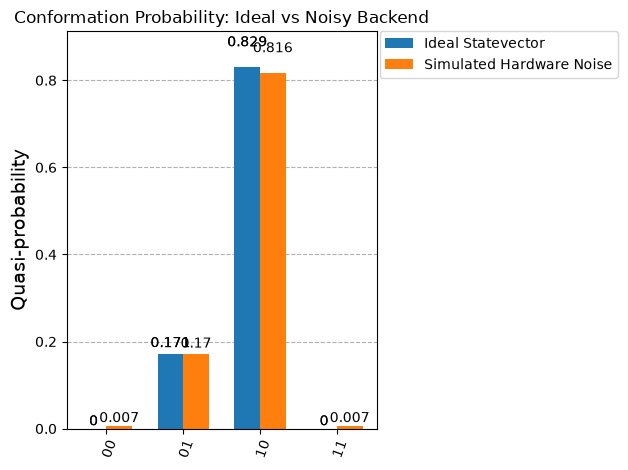

In [6]:
from qiskit_aer import AerSimulator
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager
from qiskit_aer.noise import NoiseModel, depolarizing_error
from qiskit.visualization import plot_histogram

# 1. Build a realistic 2-qubit depolarizing noise model
noise_model = NoiseModel()
error_1q = depolarizing_error(0.001, 1)
error_2q = depolarizing_error(0.015, 2)
noise_model.add_all_qubit_quantum_error(error_1q, ["rz", "sx", "x"])
noise_model.add_all_qubit_quantum_error(error_2q, ["cx"])

# 2. Transpile the optimal ansatz circuit for realistic IBM hardware basis gates
pm = generate_preset_pass_manager(optimization_level=3, basis_gates=["ecr", "id", "rz", "sx", "x"])
transpiled_circuit = pm.run(final_circuit)

print("Transpiled Circuit Depth :", transpiled_circuit.depth())
print("Transpiled Gate Count    :", transpiled_circuit.count_ops())

# 3. Simulate execution on a noisy backend
noisy_sim = AerSimulator(noise_model=noise_model)
transpiled_circuit_with_meas = transpiled_circuit.copy()
transpiled_circuit_with_meas.measure_all()
noisy_counts = noisy_sim.run(transpiled_circuit_with_meas, shots=2048).result().get_counts()

print("Noisy Measurement Counts :", noisy_counts)

# 4. Compare ideal statevector probabilities vs noisy simulation
plot_histogram(
    [probs, {k.replace(" ", ""): v / 2048 for k, v in noisy_counts.items()}],
    legend=["Ideal Statevector", "Simulated Hardware Noise"],
    title="Conformation Probability: Ideal vs Noisy Backend"
)